Миллионы людей ежедневно пользуются поиском по картинкам в Яндексе. 
Команда Яндекса прикладывает много усилий чтобы сделать сервис более полезным и удобным. 
Но для этого нужно хорошо понимать, какие задачи решают пользователи. К примеру, есть гипотеза, что интересы людей, ищущих картинки на мобильных устройствах и на десктопных компьютерах, заметно отличаются.
Вам нужно проверить эту гипотезу, сравнив запросы на разных платформах.

В файле data.json лежит выборка запросов к Яндекс Картинкам за несколько недель.
Каждый запрос описан словарем со следующими параметрами:
```
    query - текст запроса
    ts - timestamp запроса
    platform - платформа (touch - мобильный устройства, desktop - компьютеры)
```
Во время интервью Вам будет предложено ответить на ряд вопросов на основе имеющихся данных.

В ходе работы над задачей Вам будет разрешено использовать любые дополнительные материалы, поисковые системы и т.п.

**Примеры вопросов, которые могут быть заданы**
1. Выведите топ-10 самых частотных запросов в каждой платформе (desktop, touch). Какие отличия Вы видите?
2. Посмотрите, чем отличается трафик запросов в течение дня. Как можно объяснить отличие?
3. Выделите тематики запросов, контрастные для мобильных и компьютеров. Являются ли различия статистически значимыми?

In [ ]:
# Ваш код

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /home/arthur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from pathlib import Path

data_path = Path("data.json")
df = pd.read_json(data_path)

## Трафик запросов. Временные ряды.

In [6]:
df.head(3)

,query,ts,platform,querr_datetime
0,порно фото,1631786697,touch,2021-09-16 10:04:57
1,малевич картины,1631806465,desktop,2021-09-16 15:34:25
2,Секс,1631781583,touch,2021-09-16 08:39:43


In [5]:
df["querr_datetime"] = pd.to_datetime(df.ts, unit="s")

In [16]:
group_by_hour = (
    df.groupby([df.platform, df["querr_datetime"].dt.floor("h")])["query"]
    .count()
    .reset_index(name="count")
)

In [17]:
group_by_hour

,platform,querr_datetime,count
0,desktop,2021-08-31 21:00:00,360
1,desktop,2021-08-31 22:00:00,191
2,desktop,2021-08-31 23:00:00,152
3,desktop,2021-09-01 00:00:00,139
4,desktop,2021-09-01 01:00:00,168
...,...,...,...
1003,touch,2021-09-21 16:00:00,2339
1004,touch,2021-09-21 17:00:00,2581
1005,touch,2021-09-21 18:00:00,2418
1006,touch,2021-09-21 19:00:00,1954


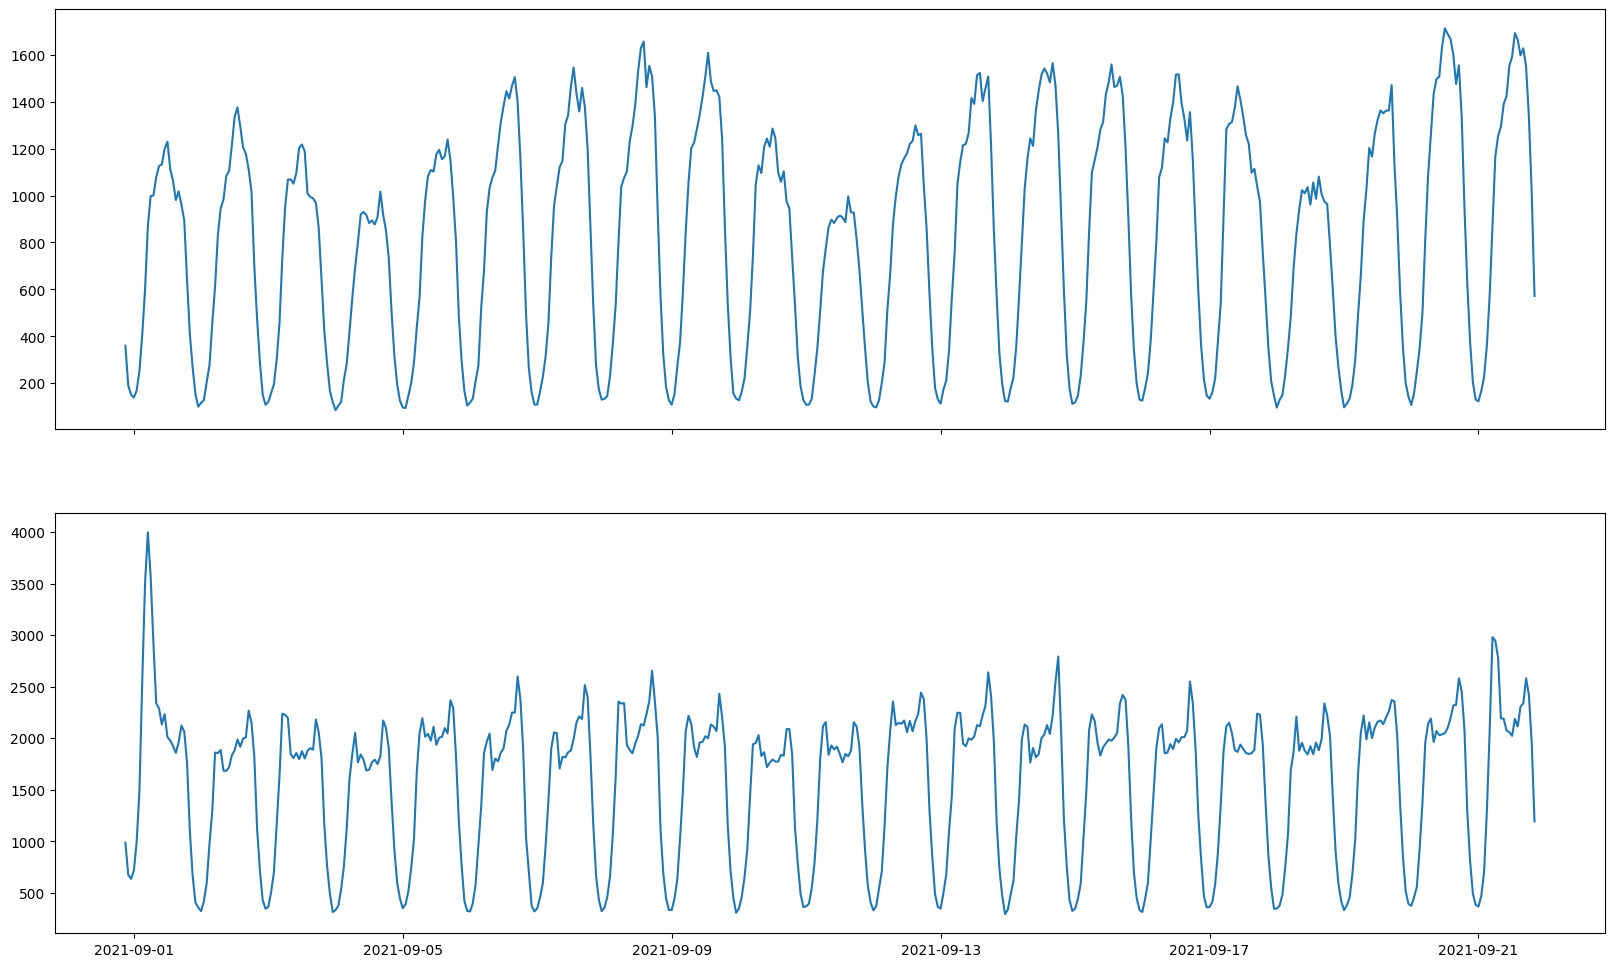

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True)
fig.set_size_inches(20, 12)
ax[0].plot(
    group_by_hour.loc[group_by_hour["platform"] == "desktop", "querr_datetime"],
    group_by_hour.loc[group_by_hour["platform"] == "desktop", "count"],
)
ax[1].plot(
    group_by_hour.loc[group_by_hour["platform"] == "touch", "querr_datetime"],
    group_by_hour.loc[group_by_hour["platform"] == "touch", "count"],
)
plt.show()

In [44]:
pivot_df = group_by_hour.pivot_table(
    index="querr_datetime", columns="platform", values="count"
)

In [45]:
pivot_df.asfreq("h")

platform,desktop,touch
querr_datetime,,
2021-08-31 21:00:00,360.0,987.0
2021-08-31 22:00:00,191.0,675.0
2021-08-31 23:00:00,152.0,635.0
2021-09-01 00:00:00,139.0,715.0
2021-09-01 01:00:00,168.0,991.0
...,...,...
2021-09-21 16:00:00,1628.0,2339.0
2021-09-21 17:00:00,1548.0,2581.0
2021-09-21 18:00:00,1333.0,2418.0


In [91]:
pivot_df["h"] = pivot_df.index.hour
pivot_df["weekday"] = pivot_df.index.day_of_week

In [92]:
pivot_df

platform,desktop,touch,h,weekday
querr_datetime,,,,
2021-08-31 21:00:00,360.0,987.0,21,1
2021-08-31 22:00:00,191.0,675.0,22,1
2021-08-31 23:00:00,152.0,635.0,23,1
2021-09-01 00:00:00,139.0,715.0,0,2
2021-09-01 01:00:00,168.0,991.0,1,2
...,...,...,...,...
2021-09-21 16:00:00,1628.0,2339.0,16,1
2021-09-21 17:00:00,1548.0,2581.0,17,1
2021-09-21 18:00:00,1333.0,2418.0,18,1


<Axes: xlabel='h'>

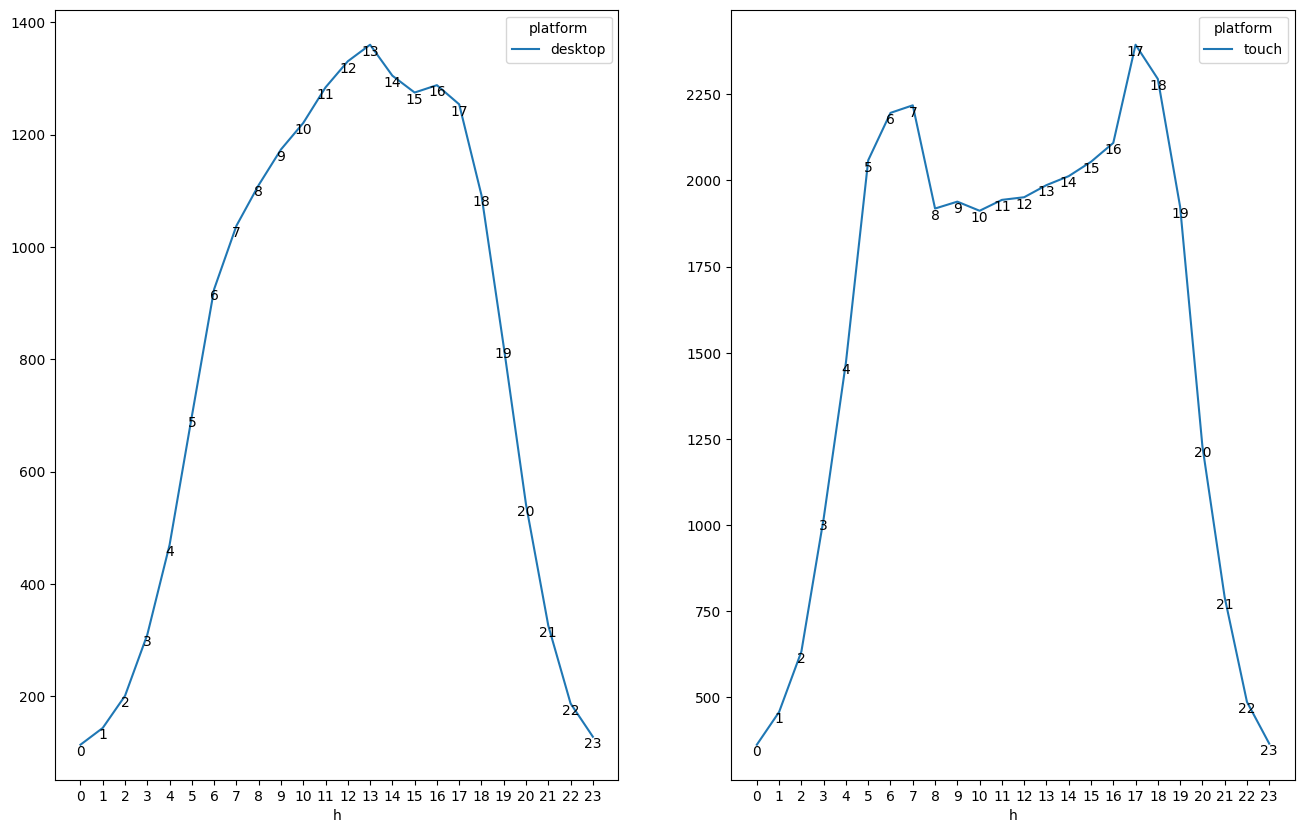

In [96]:
from itertools import product

pivot_df_touch = pivot_df.drop(columns=["desktop", "weekday"]).groupby("h").mean()
pivot_df_desktop = pivot_df.drop(columns=["touch", "weekday"]).groupby("h").mean()


fig, (ax_desktop, ax_touch) = plt.subplots(1, 2)
fig.set_size_inches(16, 10)
ax_desktop.set_xticks(pivot_df["h"].unique())
ax_touch.set_xticks(pivot_df["h"].unique())

for hour, ax_w_df in product(
    pivot_df["h"].unique(), ((pivot_df_touch, ax_touch), (pivot_df_desktop, ax_desktop))
):
    value = ax_w_df[0].loc[ax_w_df[0].index == hour].values.item()
    ax_w_df[1].text(hour, value, f"{hour}", ha="center", va="top")

    # print(hour, current_df)

pivot_df_touch.plot(ax=ax_touch)
pivot_df_desktop.plot(ax=ax_desktop)

<Axes: xlabel='weekday'>

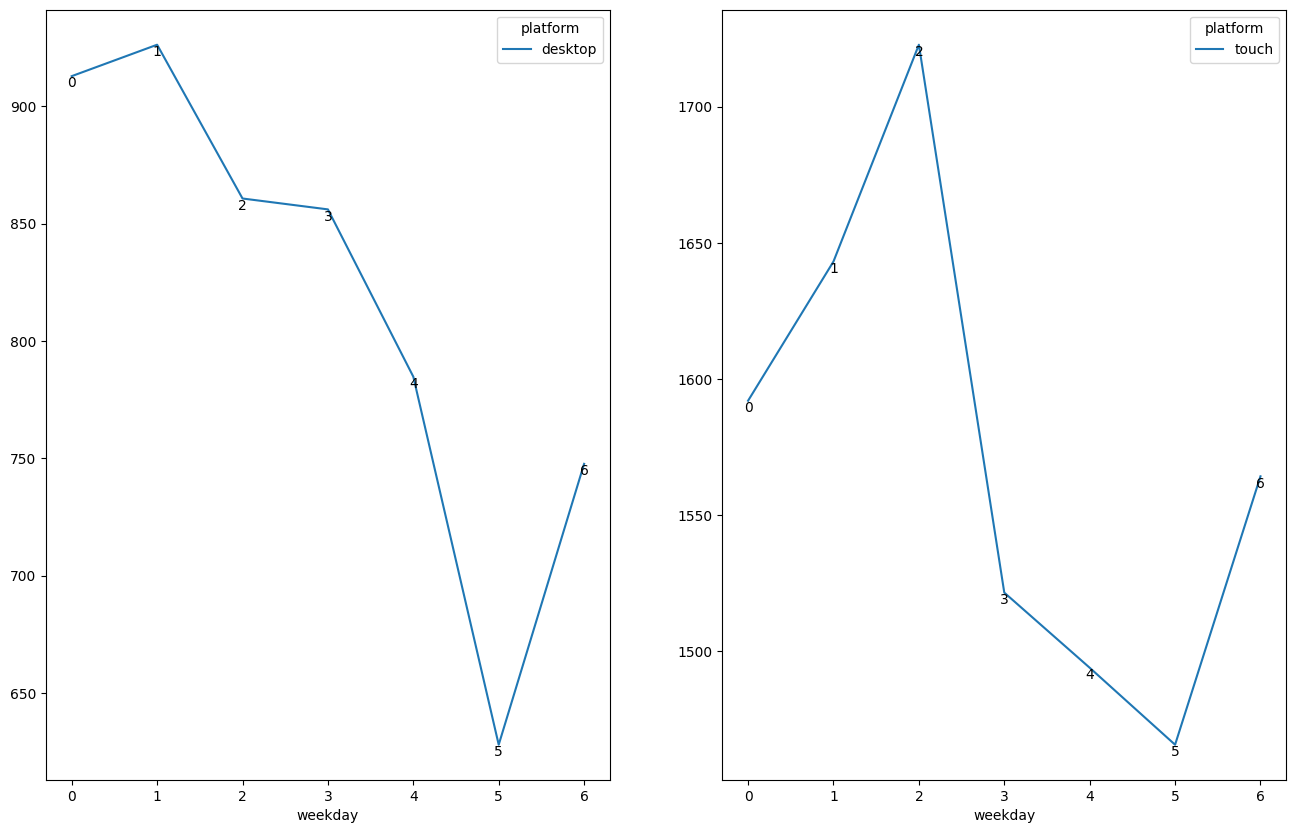

In [97]:
from itertools import product

pivot_df_touch = pivot_df.drop(columns=["desktop", "h"]).groupby("weekday").mean()
pivot_df_desktop = pivot_df.drop(columns=["touch", "h"]).groupby("weekday").mean()


fig, (ax_desktop, ax_touch) = plt.subplots(1, 2)
fig.set_size_inches(16, 10)
ax_desktop.set_xticks(pivot_df["weekday"].unique())
ax_touch.set_xticks(pivot_df["weekday"].unique())

for w, ax_w_df in product(
    pivot_df["weekday"].unique(),
    ((pivot_df_touch, ax_touch), (pivot_df_desktop, ax_desktop)),
):
    value = ax_w_df[0].loc[ax_w_df[0].index == w].values.item()
    ax_w_df[1].text(w, value, f"{w}", ha="center", va="top")

    # print(hour, current_df)

pivot_df_touch.plot(ax=ax_touch)
pivot_df_desktop.plot(ax=ax_desktop)

In [102]:
pivot_df_touch_weekend = (
    pivot_df.drop(columns=["desktop"])
    .loc[pivot_df["weekday"].isin([5, 6])]
    .groupby("h")
    .mean()
)

<Axes: xlabel='h'>

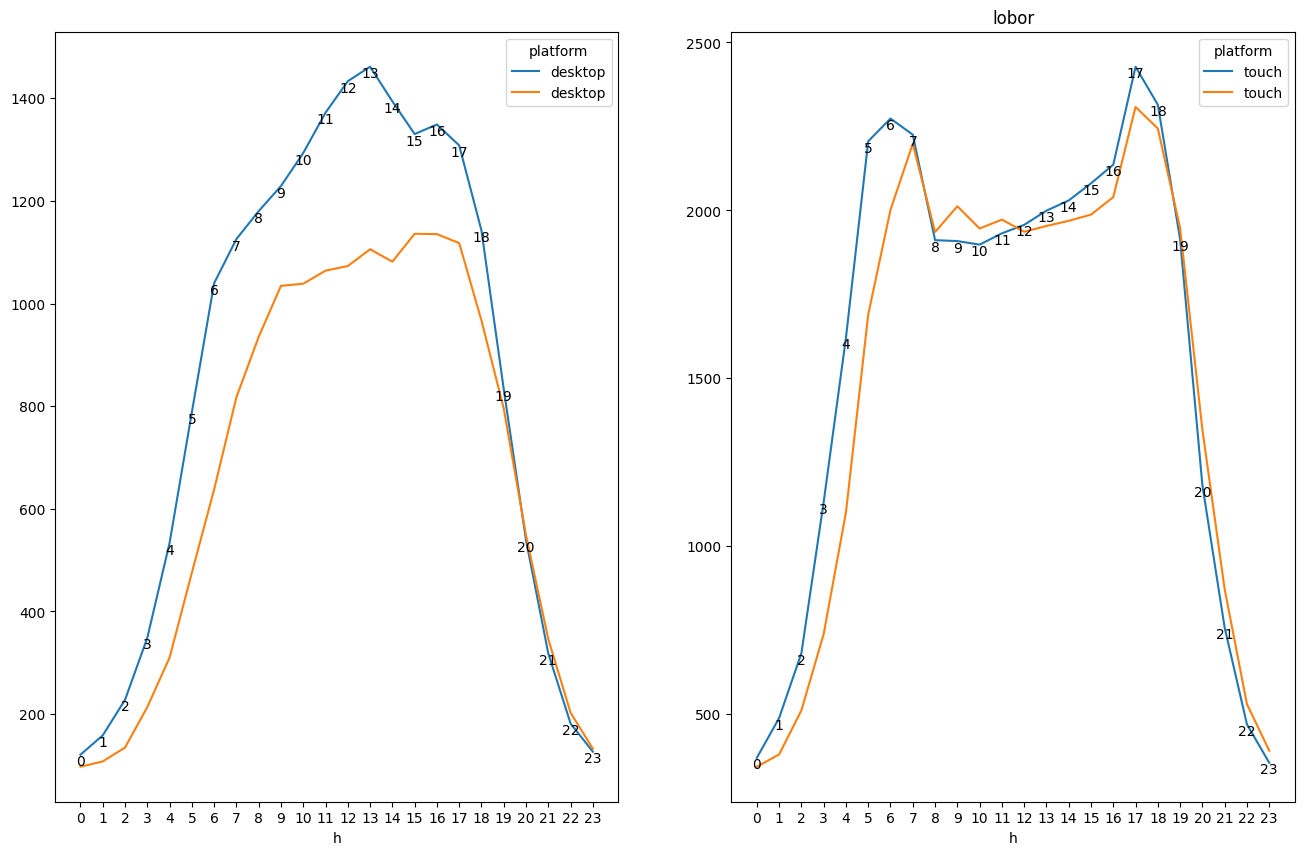

In [ ]:
from itertools import product

pivot_df_touch_weekend = (
    pivot_df.drop(columns=["desktop"])
    .loc[pivot_df["weekday"].isin([5, 6]), ["touch", "h"]]
    .groupby("h")
    .mean()
)
pivot_df_touch_labor_day = (
    pivot_df.drop(columns=["desktop"])
    .loc[~pivot_df["weekday"].isin([5, 6]), ["touch", "h"]]
    .groupby("h")
    .mean()
)
pivot_df_desktop_weekend = (
    pivot_df.drop(columns=["touch"])
    .loc[pivot_df["weekday"].isin([5, 6]), ["desktop", "h"]]
    .groupby("h")
    .mean()
)
pivot_df_desktop_labor_day = (
    pivot_df.drop(columns=["touch"])
    .loc[~pivot_df["weekday"].isin([5, 6]), ["desktop", "h"]]
    .groupby("h")
    .mean()
)


fig, (ax_desktop, ax_touch) = plt.subplots(1, 2)
fig.set_size_inches(16, 10)
ax_desktop.set_xticks(pivot_df["h"].unique())
ax_touch.set_xticks(pivot_df["h"].unique())

for hour, ax_w_df in product(
    pivot_df["h"].unique(),
    ((pivot_df_touch_labor_day, ax_touch), (pivot_df_desktop_labor_day, ax_desktop)),
):
    value = ax_w_df[0].loc[ax_w_df[0].index == hour].values.item()
    ax_w_df[1].text(hour, value, f"{hour}", ha="center", va="top")

    # print(hour, current_df)

pivot_df_touch_labor_day.plot(ax=ax_touch)
pivot_df_desktop_labor_day.plot(ax=ax_desktop)
pivot_df_touch_weekend.plot(ax=ax_touch)
pivot_df_desktop_weekend.plot(ax=ax_desktop)

## Интересы пользователь - log odds

In [ ]:
# 1. нормализировать .lower()
# 2. частотные слова
# 3. заменить ё на е
# 4. посчитать слова.

,query,ts,platform
0,порно фото,1631786697,touch
1,малевич картины,1631806465,desktop
2,Секс,1631781583,touch
3,с днём рождения лена,1631771563,touch
4,зверополис порно,1631787599,touch


In [37]:
[w for x in [x.split() for x in df["query"].values[:20]] for w in x]

['порно',
 'фото',
 'малевич',
 'картины',
 'Секс',
 'с',
 'днём',
 'рождения',
 'лена',
 'зверополис',
 'порно',
 'алабай',
 'собака',
 'фото',
 'бактериофаг',
 'полина',
 'гагарина',
 'кадр',
 'из',
 'фильма',
 'porno',
 'кухни',
 'дизайн',
 'айфон',
 '13',
 'картинки',
 'чупапи',
 'муняню',
 'драцена',
 'n',
 'u',
 'd',
 'e',
 'l_i_t_t_l_e',
 'g_i_r_l_s',
 'kids',
 'доброе',
 'утро',
 'четверга',
 'байден',
 'снилс',
 'секс',
 'с',
 'девственницей']

## Интересы пользователей 

In [4]:
df = pd.read_json(data_path)

In [161]:
import pyperclip

In [164]:
pyperclip.copy(df.iloc[:20, :].to_csv(index=True, encoding="cp1251", sep=","))

In [18]:
ru_stop_words = stopwords.words("russian")

In [108]:
from string import whitespace, punctuation

In [139]:
df["words"] = df["query"].str.lower().str.split()

In [136]:
print("(социальная")

(социальная


In [141]:
df.loc[df["query"].str.contains(r"\(социальная"), :]

,query,ts,platform,words
271,одноклассники (социальная сеть,1631633571,desktop,"[одноклассники, социальная, сеть]"
601,одноклассники (социальная сеть,1631289367,desktop,"[одноклассники, социальная, сеть]"
2279,одноклассники (социальная сеть,1631644057,desktop,"[одноклассники, социальная, сеть]"
2819,одноклассники (социальная сеть,1632031689,desktop,"[одноклассники, социальная, сеть]"
3460,одноклассники (социальная сеть,1631633358,desktop,"[одноклассники, социальная, сеть]"
...,...,...,...,...
1200871,одноклассники (социальная сеть,1632243304,desktop,"[одноклассники, социальная, сеть]"
1201029,одноклассники (социальная сеть,1631165538,desktop,"[одноклассники, социальная, сеть]"
1201392,одноклассники (социальная сеть,1631155825,desktop,"[одноклассники, социальная, сеть]"
1201677,одноклассники (социальная сеть,1631971723,desktop,"[одноклассники, социальная, сеть]"


In [140]:
df["words"] = df["words"].apply(
    lambda x: [w.strip(whitespace + punctuation) for w in x if w not in ru_stop_words]
)

In [142]:
df_touch = df.loc[df["platform"] == "touch", "words"].tolist()
df_desktop = df.loc[df["platform"] == "desktop", "words"].tolist()

In [39]:
from collections import Counter

In [143]:
freq_touch = Counter([w for query in df_touch for w in query])
freq_desktop = Counter([w for query in df_desktop for w in query])

In [113]:
from pprint import pprint

In [144]:
pprint(freq_touch.most_common(10))
pprint("-----------")
pprint(freq_desktop.most_common(10))

[('рождения', 55989),
 ('днём', 48650),
 ('картинки', 28183),
 ('порно', 23757),
 ('днем', 17561),
 ('2021', 16518),
 ('женщине', 16403),
 ('секс', 16355),
 ('сентября', 15912),
 ('фото', 15826)]
'-----------'
[('календарь', 9797),
 ('2021', 9441),
 ('таблица', 9402),
 ('картинки', 8442),
 ('карта', 6619),
 ('фото', 5996),
 ('рождения', 5786),
 ('алфавит', 5731),
 ('обои', 5731),
 ('фон', 5572)]


In [145]:
all_words = freq_desktop.keys() | freq_touch.keys()

In [146]:
all_words = set([w for w in all_words if (freq_desktop[w] + freq_touch[w]) > 60])

In [147]:
total_touch = freq_touch.total()
total_desktop = freq_desktop.total()

In [118]:
import numpy as np

In [148]:
odd_dict = {}
alpha = 1  # сглаживание
for word in all_words:
    ratio_touch = (freq_touch.get(word, 0) + alpha) / (
        total_touch + alpha * len(all_words)
    )
    ratio_desktop = (freq_desktop.get(word, 0) + alpha) / (
        total_desktop + alpha * len(all_words)
    )
    odd_dict[word] = np.log(ratio_touch / ratio_desktop)

In [149]:
# топ для touch
sorted(odd_dict.items(), key=lambda x: -x[1])[:20]

[('colmek', np.float64(4.596694650151687)),
 ('apetube', np.float64(4.540124298663293)),
 ('korea', np.float64(4.373551098837478)),
 ('привлекательности', np.float64(4.302323589549109)),
 ('indo', np.float64(4.2376359148576785)),
 ('pap', np.float64(4.232851216734343)),
 ('tetek', np.float64(4.188726411825404)),
 ('kontol', np.float64(4.012401874503824)),
 ('pokerdom', np.float64(3.9618163777157176)),
 ('tt', np.float64(3.942768182745023)),
 ('besar', np.float64(3.8833447622742225)),
 ('bocah', np.float64(3.79261590888446)),
 ('bokep', np.float64(3.7730882760041893)),
 ('xnxxx', np.float64(3.6486552199629516)),
 ('cewek', np.float64(3.6024423768078204)),
 ('hanabi', np.float64(3.5610571606449657)),
 ('视频', np.float64(3.546872525653009)),
 ('подружка', np.float64(3.546872525653009)),
 ('рейтинг', np.float64(3.453346467642186)),
 ('jepang', np.float64(3.4505414167145774))]

In [150]:
# топ для desktop
sorted(odd_dict.items(), key=lambda x: x[1])[:20]

[('яндекс.почта', np.float64(-5.889008522237105)),
 ('услуг', np.float64(-5.778877697834001)),
 ('государственных', np.float64(-5.778877697834001)),
 ('iii', np.float64(-5.2554996079968905)),
 ('modern', np.float64(-5.201432386726615)),
 ('warfare', np.float64(-5.201432386726615)),
 ('online', np.float64(-5.178959530874556)),
 ('stalker', np.float64(-5.120463324192947)),
 ('counter-strike', np.float64(-5.083649351070231)),
 ('global', np.float64(-5.083649351070231)),
 ('facebook.com', np.float64(-5.083649351070231)),
 ('offensive', np.float64(-5.083649351070231)),
 ('iv', np.float64(-5.0583315430859415)),
 ('v', np.float64(-4.978288835412405)),
 ('theft', np.float64(-4.969920585741888)),
 ('auto', np.float64(-4.969920585741888)),
 ('zuma', np.float64(-4.935729220993609)),
 ('deluxe', np.float64(-4.935729220993609)),
 ('grand', np.float64(-4.921130421572456)),
 ('кадры', np.float64(-4.8407812944082425))]

## Временные ряды

## Прочие


In [75]:
# Примеры:

# "()" → True
# "()[]{}" → True
# "(]" → False
# "([)]" → False
# "{[]}" → True


def valid_brackets(s: str) -> dict:

    if s[0] in ("}", ")", "]"):
        return False

    MAPPING = dict((("}", "{"), (")", "("), ("]", "[")))

    current = []
    for b in s:
        if b in ("{", "(", "["):
            current.append(b)
        else:
            if (not current) or (current[-1] != MAPPING[b]):
                return False
            else:
                current.pop()
    return not current


s = "((()))"
print(valid_brackets(s))

True


In [ ]:
# Максимальная длина подстроки без повторов

# Дана строка s.
# Нужно вернуть длину самой длинной подстроки без повторяющихся символов.

# Примеры:

# "abcabcbb" → 3
# "bbbbb" → 1
# "pwwkew" → 3

In [39]:
list_letter = list("wpwwkew")
list_letter.index("w", 1)
list_letter[:1] = []
list_letter

['p', 'w', 'w', 'k', 'e', 'w']

In [48]:
def find_max_substring(s: str) -> int:
    current_substring = []
    max_substring = 0
    for l in s:
        if l in current_substring:
            index = current_substring.index(l)
            current_substring[: index + 1] = []
            current_substring.append(l)
        else:
            current_substring.append(l)
            max_substring = max(len(current_substring), max_substring)
    return max_substring, current_substring

In [49]:
s = "abba"
print(find_max_substring(s))

(2, ['b', 'a'])


In [ ]:
# Следующий уровень

# Давай усложним, но в ту же тему.

# Задача 8. Минимальное окно

# Даны строки s и t.
# Нужно найти минимальную подстроку в s, которая содержит все символы строки t (с учетом количества).

# Пример:

# s = "ADOBECODEBANC", t = "ABC" → "BANC"

# Если нет — вернуть пустую строку.

In [ ]:
def find_max_substring(s: str) -> int:
    seen = {}
    shift = 0
    maximum_in_row = 0
    for i, letter in enumerate(s, start=1):
        if letter not in seen.keys():
            maximum_in_row = maximum_in_row(i - shift, maximum_in_row)
            seen[letter] = i
        else:
            shift = seen[letter]
            seen[letter] = i
    return maximum_in_row


# "abcabcbb" → 3
# "bbbbb" → 1
# "pwwkew" → 3

s = "abba"
print(find_max_substring(s))

2


In [17]:
print(find_max_substring("abcabcbb"))  # 3
print(find_max_substring("bbbbb"))  # 1
print(find_max_substring("pwwkew"))  # 3
print(find_max_substring("abba"))  # 2

3
1
3
2


In [ ]:
# Давай усложним, но в ту же тему.

# Задача 8. Минимальное окно

# Даны строки s и t.
# Нужно найти минимальную подстроку в s, которая содержит все символы строки t (с учетом количества).

# Пример:

# s = "ADOBECODEBANC", t = "ABC" → "BANC"

# Если нет — вернуть пустую строку.

# Это уже реальный middle уровень.
# Жду твою попытку.

In [ ]:
from itertools import map


def find_min_window(s: str, t: str = "wk") -> int:

    def _checker(current_subsequence: dict, condition: str):
        return all(map(lambda x: x in current_subsequence.keys, condition))

    seen = {}
    shift, max_seq = 0, 0
    check = list(t)
    checker = False

    for i, j in enumerate(s, start=1):
        if j not in seen:
            seen[j] = i


# print(find_min_window("abcabcbb"))  # 3
# print(find_min_window("bbbbb"))     # 1
# print(find_min_window("pwwkew"))    # 3
print(find_min_window("ADOBECODEBANC", "ABC"))  # 2

текущая буква A
текущая max_seq 0
текущая check ['A', 'B', 'C']
текущая буква D
текущая max_seq 1
текущая check ['B', 'C']
текущая буква O
текущая max_seq 1
текущая check ['B', 'C']
текущая буква B
текущая max_seq 1
текущая check ['B', 'C']
текущая буква E
текущая max_seq 4
текущая check ['C']
текущая буква C
текущая max_seq 4
текущая check ['C']
текущая буква O
текущая max_seq 6
текущая check []
текущая буква D
текущая max_seq 6
текущая check ['A', 'D', 'B', 'E', 'C']
текущая буква E
текущая max_seq 6
текущая check ['A', 'D', 'B', 'E', 'C', 'A', 'O', 'B', 'E', 'C']
текущая буква B
текущая max_seq 6
текущая check ['A', 'D', 'B', 'E', 'C', 'A', 'O', 'B', 'E', 'C', 'A', 'D', 'O', 'B', 'C']
текущая буква A
текущая max_seq 6
текущая check ['A', 'D', 'B', 'E', 'C', 'A', 'O', 'B', 'E', 'C', 'A', 'D', 'O', 'B', 'C', 'A', 'D', 'O', 'E', 'C']
текущая буква N
текущая max_seq 6
текущая check ['A', 'D', 'B', 'E', 'C', 'A', 'O', 'B', 'E', 'C', 'A', 'D', 'O', 'B', 'C', 'A', 'D', 'O', 'E', 'C', 'D', 

In [ ]:
# input: ["eat", "tea", "tan", "ate", "nat", "bat"]

# output: [
#     ["eat", "tea", "ate"],
#     ["tan", "nat"],
#     ["bat"]
# ]

In [ ]:
from collections import Counter

In [ ]:
from typing import Dict, List

s = ["aa", "a"]


def to_find_anogramm(s):
    seen: Dict[str, List[str]] = {}
    for w in s:
        if (k := "".join((sorted(w)))) in seen.keys():
            seen[k] = seen[k] + [w]
        else:
            seen[k] = [w]
    return list(seen.values())


to_find_anogramm(s)

[['aa'], ['a']]

In [10]:
s = ["eat", "tea", "tan", "ate", "nat", "bat"]
new_s = sorted(["".join(sorted(x)) for x in s])
new_s

['abt', 'aet', 'aet', 'aet', 'ant', 'ant']

In [29]:
s = "eat"
hash(tuple(sorted(s)))

605866812783342437

In [ ]:
# Следующая задача полегче, но с подвохом:

# Удалить дубликаты с сохранением порядка

# Дан список чисел nums.
# Нужно вернуть новый список, где удалены повторяющиеся элементы, но порядок первого появления сохранён.

# Пример:

# [3, 1, 3, 2, 1, 4] -> [3, 1, 2, 4]

In [19]:
from typing import Optional


def remove_seen(l: list) -> list:
    seen = set()
    result = []
    for d in l:
        if d not in seen:
            result.append(d)
            seen.add(d)
    return result


remove_seen([3, 1, 3, 2, 1, 4])

[3, 1, 2, 4]

In [17]:
list(dict.fromkeys([3, 1, 3, 2, 1, 4]))

[3, 1, 2, 4]

In [ ]:
# Дана строка s.
# Можно удалить не более одного символа.

# Нужно вернуть True, если после этого строка может стать палиндромом, иначе False.

# Примеры:

# "aba"      -> True
# "abca"     -> True   # удаляем 'c'
# "abc"      -> False
# "deeee"    -> True

# Подсказка: попробуй идти двумя указателями — слева и справа.

In [ ]:
s = "aba"


def find_palindrome(s):

    left, right = 0, len(s) - 1

    def _is_palindrome(left: int, right: int) -> bool:

        while left < right:
            if s[left] != s[right]:
                return False
            left += 1
            right -= 1
        return True

    while left < right:
        if s[left] != s[right]:
            return _is_palindrome(s, left + 1, right) or _is_palindrome(
                s, left, right - 1
            )
        left += 1
        right -= 1

    return True


find_palindrome(s)

True

In [ ]:
def find_palindrome(s: str) -> bool:

    right_shift = len(s)
    left_shift = 0

    current_word = list(s)
    flag_remove = False
    print("starting...")
    for i in range(len(current_word) // 2):
        if s[i + left_shift] == s[-(i + right_shift)]:
            print(s[i + left_shift], s[-(i + right_shift)])
            continue
        elif (s[i + left_shift + 1] == s[-(i + right_shift)]) and (
            flag_remove is False
        ):
            print((s[i + left_shift + 1], s[-(i + right_shift)]))
            left_shift += 1
            flag_remove = True
        elif (s[i + left_shift] == s[-(i + right_shift + 1)]) and (
            flag_remove is False
        ):
            print((s[i + left_shift], s[-(i + right_shift + 1)]))
            right_shift += 1
            flag_remove = True
        else:
            return False
    return True


find_palindrome("eeccccbebaeeabebccceea")

starting...
('e', 'e')
e e
c c
c c
c c


False

In [ ]:
# Задача 10. Container With Most Water

# Дан список высот:

# height = [1,8,6,2,5,4,8,3,7]

# Каждый элемент — высота вертикальной линии.

# Нужно найти две линии, которые вместе с осью X образуют контейнер с максимальной площадью.

# Площадь:

# min(height[left], height[right]) * (right - left)
# Пример
# [1,8,6,2,5,4,8,3,7]

# Ответ:

# 49

# (между 8 и 7)

In [27]:
from typing import List


def find_max_square(height: List[int]):
    squeres: set = set()
    x_length = len(height)
    for i in range(x_length):
        for j in range(x_length):
            squeres.add(min(height[i], height[j]) * abs(i - j))
    return max(squeres)


find_max_square([1, 8, 6, 2, 5, 4, 8, 3, 7])

49

In [ ]:
from typing import List


def find_max_square(height: List[int]):
    right: int = len(height) - 1
    left: int = 0
    s: int = 0
    while left < right:
        print(left, right)
        s = max(s, min(height[left], height[right]) * (right - left))
        if height[left] < height[right]:
            left += 1
        else:
            right -= 1
    return s


find_max_square([1, 8, 6, 2, 5, 4, 8, 3, 7])

0 8
1 8
1 7
1 6
1 5
1 4
1 3
1 2


49

In [ ]:
nums = [1, 2, 3, 4]
from functools import reduce
from itertools import product


def product_others(nums: list) -> list:
    result = []
    for idx in range(len(nums)):
        result.append(
            reduce(lambda x, y: x * y, [x for i, x in enumerate(nums) if i != idx])
        )
    return result


product_others(nums)

[24, 12, 8, 6]

In [14]:
nums = [1, 2, 3, 4, 10, 0]


def product_others(nums: list) -> list:

    def prod(con):
        result = 1
        for i in con:
            result *= i
        return result

    result = []
    for idx in range(len(nums)):
        result.append(prod([x for i, x in enumerate(nums) if i != idx]))
    return result


product_others(nums)

[0, 0, 0, 0, 0, 240]

In [36]:
nums = [1, 2, 3, 4, 10]


def product_others(nums: list) -> list:
    n = len(nums)
    result = [1] * n

    left_prod = 1
    for i in range(n):
        result[i] = left_prod
        left_prod *= nums[i]

    right_prod = 1
    for i in range(n - 1, -1, -1):
        result[i] *= right_prod
        right_prod *= nums[i]

    return result


product_others(nums)

[240, 120, 80, 60, 24]

In [32]:
for i in range(10, -1, -1):
    print(i)

10
9
8
7
6
5
4
3
2
1
0


In [ ]:
from typing import List
from collections import defaultdict

nums = [[4, 5], [6, 8], [6, 5], [4, 9]]
nums_two = [[9, 1]]
output = [8, 6, 5, 4, 9]


def find_output(nums: List[List[int]]) -> List[int]:

    nb = defaultdict(list)

    for i, j in nums:
        nb[i].append(j)
        nb[j].append(i)
    start = next(x for x in nb if len(nb[x]) == 1)
    result = [start]
    prev = None
    current = start

    while len(result) < len(nums) + 1:

        for l in nb[current]:
            if l != prev:

                result.append(l)

                prev, current = current, l
                break

    return result


print(find_output(nums))

[8, 6, 5, 4, 9]
